In [97]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.


# Read the Data

In [98]:
import pandas as pd

df = pd.read_csv("Airline.csv")
df.head(2)


,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,1,IndiGo,24-03-2019,Banglore,New Delhi,BLR _ DEL,22:20,22-03-2026 01:10,2h 50m,non-stop,No info,3897.0
1,2,Air India,01-05-2019,Kolkata,Banglore,CCU _ IXR _ BBI _ BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0


In [99]:
#


# Handle the Null Values

In [100]:
df.isnull().sum()


ID                 0
Airline            0
Date_of_Journey    0
Source             2
Destination        2
Route              3
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              3
dtype: int64

In [101]:
# Handle Null Values from Price
# Drop or replace the null with mean/median

df[df['Price'].isnull()]
mean_Price = df["Price"].mean()
mean_Price
df.fillna({'Price':mean_Price},inplace=True)



,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,1,IndiGo,24-03-2019,Banglore,New Delhi,BLR _ DEL,22:20,22-03-2026 01:10,2h 50m,non-stop,No info,3897.0
1,2,Air India,01-05-2019,Kolkata,Banglore,CCU _ IXR _ BBI _ BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0
2,3,Jet Airways,09-06-2019,Delhi,Cochin,DEL _ LKO _ BOM _ COK,09:25,10-06-2026 04:25,19h,2 stops,No info,13882.0
3,4,IndiGo,12-05-2019,Kolkata,Banglore,CCU _ NAG _ BLR,18:05,23:30,5h 25m,1 stop,No info,6218.0
4,5,IndiGo,01-03-2019,Banglore,New Delhi,BLR _ NAG _ DEL,16:50,21:35,4h 45m,1 stop,No info,13302.0
...,...,...,...,...,...,...,...,...,...,...,...,...
10684,10679,Air Asia,09-04-2019,Kolkata,Banglore,CCU ? BLR,19:55,22:25,2h 30m,non-stop,No info,4107.0
10685,10680,Air India,27-04-2019,Kolkata,Banglore,CCU ? BLR,20:45,23:20,2h 35m,non-stop,No info,4145.0
10686,10681,Jet Airways,27-04-2019,Banglore,Delhi,BLR ? DEL,08:20,11:20,3h,non-stop,No info,7229.0
10687,10682,Vistara,01-03-2019,Banglore,New Delhi,BLR ? DEL,11:30,14:10,2h 40m,non-stop,No info,12648.0


In [102]:
# Handle Missing Values of Source,Destinatoin and Stops 
# using mode(Most Frequent)
# Why are we using Mode? this is categoral columns
mode_Source = df['Source'].mode()[0]
mode_Source

df.fillna({'Source':mode_Source},inplace=True)

df[df['Source'].isnull()]


,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price


In [103]:
mode_Desti = df['Destination'].mode()[0]

df.fillna({'Destination':mode_Desti},inplace=True)
df[df['Destination'].isnull()]


,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price


In [104]:
df[df['Total_Stops'].isnull()]

mode_T_Stops =df['Total_Stops'].mode()[0]

df.fillna({'Total_Stops':mode_T_Stops},inplace=True)

df[df['Total_Stops'].isnull()]


,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price


# Remove the Duplicates

In [105]:
# Find and remove the Duplicates

df[df.duplicated()]

df.drop_duplicates(inplace=True)


In [106]:
df[df.duplicated()]


,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price


In [107]:
df.columns

for i in df.columns:
    print(i)


ID
Airline
Date_of_Journey
Source
Destination
Route
Dep_Time
Arrival_Time
Duration
Total_Stops
Additional_Info
Price


# Handle the Uneven Values

In [108]:
['Airline','Source','Destination','Total_Stops']


['Airline', 'Source', 'Destination', 'Total_Stops']

In [109]:
df['Airline'].unique()
df['Source'].unique()
df['Destination'].unique()
#df['Total_Stops'].unique()


<ArrowStringArray>
['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad']
Length: 6, dtype: str

In [110]:
df['Airline'].value_counts()
df['Airline'] = df['Airline'].replace({'Multiple carriers Premium economy':'Multiple carriers'})
df['Airline'] = df['Airline'].replace({'Jet Airways Business':'Jet Airways'})
df['Airline'] = df['Airline'].replace({'Vistara Premium economy':'Vistara'})


df['Airline'].value_counts()


Airline
Jet Airways          3855
IndiGo               2053
Air India            1752
Multiple carriers    1209
SpiceJet              818
Vistara               482
Air Asia              319
GoAir                 194
Trujet                  1
Name: count, dtype: int64

In [111]:
df["Destination"] = df["Destination"].str.replace({'New Delhi':'Delhi'})


In [112]:
df['Destination'].unique()


<ArrowStringArray>
['Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Hyderabad']
Length: 5, dtype: str

In [113]:
df.head(2)


,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,1,IndiGo,24-03-2019,Banglore,Delhi,BLR _ DEL,22:20,22-03-2026 01:10,2h 50m,non-stop,No info,3897.0
1,2,Air India,01-05-2019,Kolkata,Banglore,CCU _ IXR _ BBI _ BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0


In [114]:
# 



# Stat Based Analysis

In [115]:
df.describe()


,ID,Price
count,10683.000000,10683.000000
mean,5342.000000,9087.219176
std,3084.060797,4611.065933
min,1.000000,1759.000000
25%,2671.500000,5277.000000
50%,5342.000000,8372.000000
75%,8012.500000,12373.000000
max,10683.000000,79512.000000


# Graph Based Analysis

In [116]:
# install the liabraries
# pip install matplotlib
# pip install seaborn


In [117]:
# Import required Liabraries for Visualization

import matplotlib.pyplot as plt
import seaborn as sns


In [118]:
Air_Index = df.groupby('Airline')['Airline'].count().sort_values().index
Air_Index



Index(['Trujet', 'GoAir', 'Air Asia', 'Vistara', 'SpiceJet',
       'Multiple carriers', 'Air India', 'IndiGo', 'Jet Airways'],
      dtype='str', name='Airline')

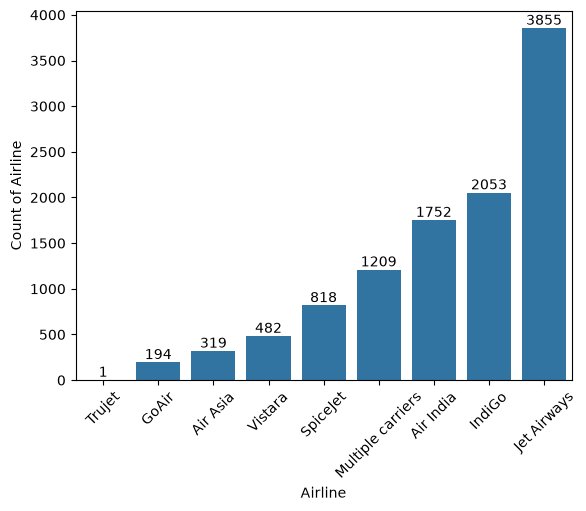

In [119]:
# Count distribution against Airline

ax = sns.countplot(x=df['Airline'],order=Air_Index)
plt.bar_label(ax.containers[0])
plt.xticks(rotation=45)
plt.ylabel('Count of Airline')
plt.show()


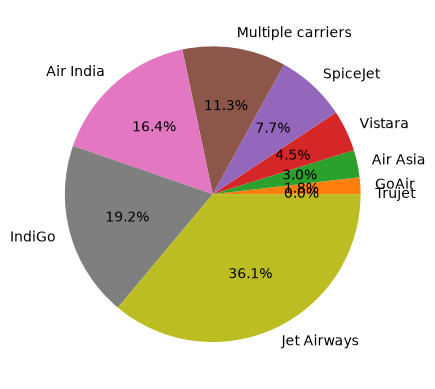

In [120]:
# Pie Chart 

Airline_count_df = df.groupby("Airline")["Airline"].count().sort_values()
Airline_count_df
plt.pie(Airline_count_df,labels=Airline_count_df.index,autopct="%1.1f%%")
plt.show()


# Jest Aiwasy is the highest contrubor in terms of counts(3855) and % wise is 36.1%
# while Truejest has lowest contribution of one flight with 0.001% 

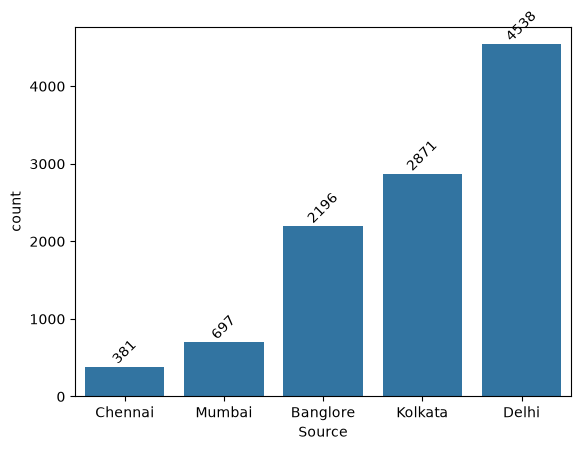

In [121]:
# Market share of each from Source

import matplotlib.pyplot as plt
import seaborn as sns

Source_count_df = df.groupby(['Source'])['Source'].count().sort_values()
Source_count_df

ax = sns.countplot(x=df['Source'],order=Source_count_df.index)
ax.bar_label(ax.containers[0],rotation=45)
plt.show()


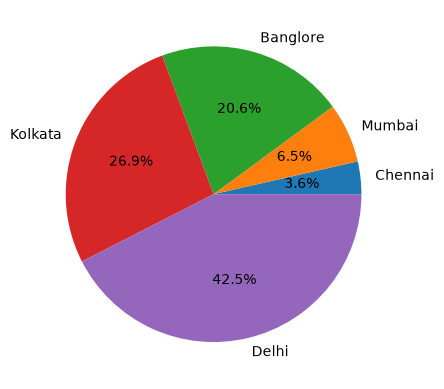

In [122]:
plt.pie(Source_count_df,labels=Source_count_df.index,autopct="%1.1f%%")
plt.show()


In [123]:
Airline_Sum_df = df.groupby("Airline")["Price"].sum().sort_values()
Airline_Sum_df


Airline
Trujet               4.140000e+03
GoAir                1.137045e+06
Air Asia             1.783293e+06
SpiceJet             3.548717e+06
Vistara              3.765546e+06
IndiGo               1.164807e+07
Multiple carriers    1.318805e+07
Air India            1.683629e+07
Jet Airways          4.516761e+07
Name: Price, dtype: float64

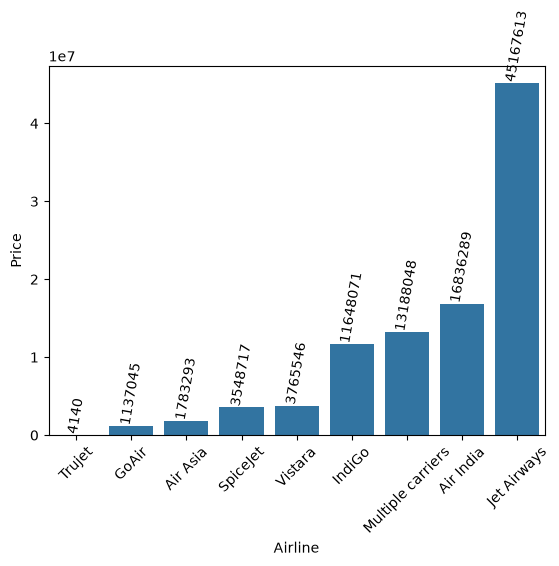

In [124]:
# Sales distribution agaisnt Ariline

ax = sns.barplot(x=df['Airline'],y=df['Price'],estimator='sum',errorbar=None,order=Airline_Sum_df.index)
plt.xticks(rotation=45)
ax.bar_label(ax.containers[0],rotation=80,fmt="%.0f")
plt.show()


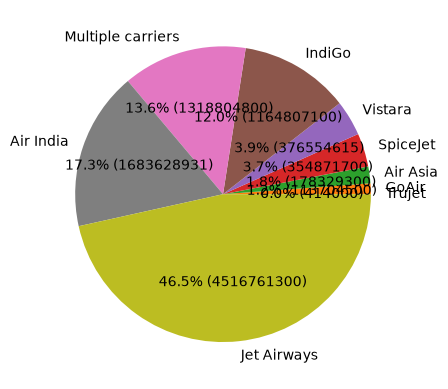

In [125]:
def label(df):
    def percentage(p):
        per = f'{p:.1f}%'
        value = f'{p * sum(df):.0f}'
        return f'{per} ({value})'
    return percentage


plt.pie(Airline_Sum_df,labels=Airline_Sum_df.index,autopct=label(Airline_Sum_df))
plt.show()


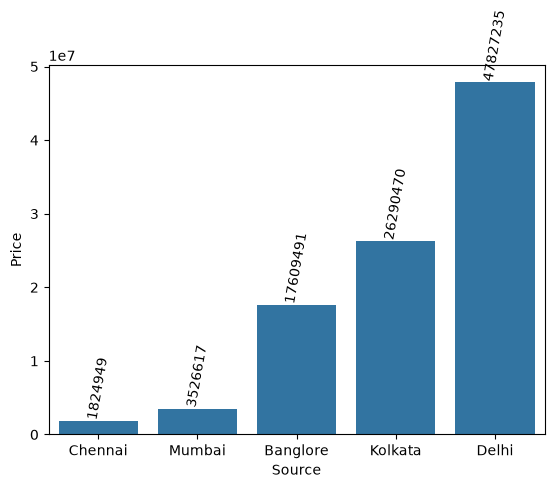

In [126]:
# Source

Source_Sum_df = df.groupby("Source")["Price"].sum().sort_values()
Source_Sum_df

ax = sns.barplot(x=df['Source'],y=df['Price'],order=Source_Sum_df.index,errorbar=None,estimator='sum')
ax.bar_label(ax.containers[0],rotation=80,fmt="%.0f")
plt.show()


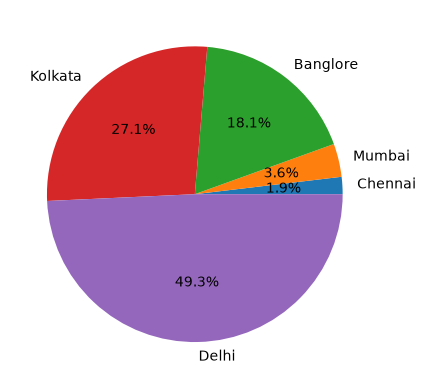

In [127]:
plt.pie(Source_Sum_df,labels=Source_Sum_df.index,autopct="%1.1f%%")
plt.show()


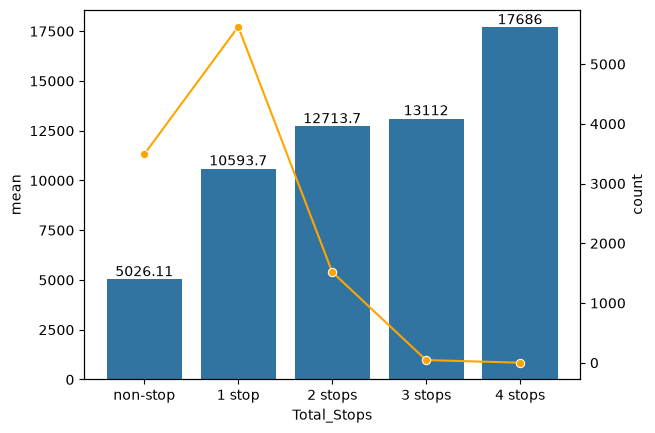

In [162]:
TtlStops_df = df.groupby("Total_Stops")["Price"].agg(['mean','count']).sort_values(by='mean')
TtlStops_df = TtlStops_df
TtlStops_df

ax = sns.barplot(TtlStops_df['mean'])
ax.bar_label(ax.containers[0])

ax.twinx()
ax2 = sns.lineplot(TtlStops_df['count'],color='orange',marker="o")
plt.show()


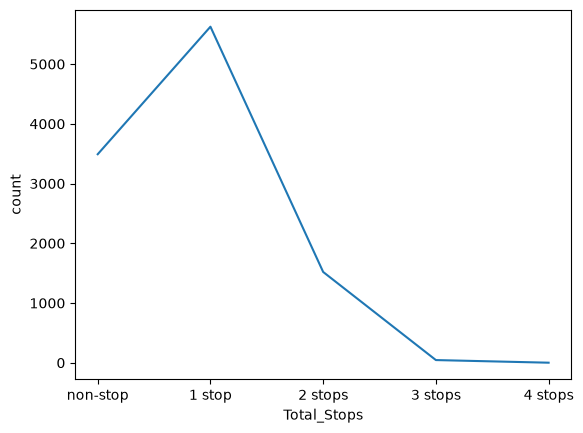

Total_Stops
non-stop    3491
1 stop      5626
2 stops     1520
3 stops       45
4 stops        1
Name: count, dtype: int64

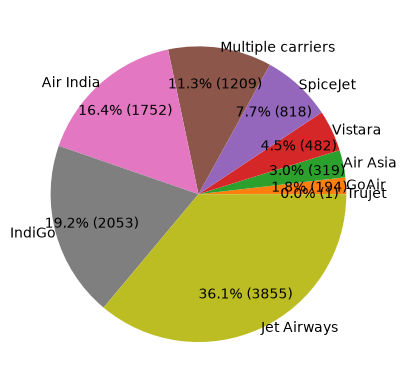

In [128]:
# Count distribution against Airline


Air_df = df.groupby('Airline')['Airline'].count().sort_values()
Air_df.reset_index
plt.pie(Air_df, labels=Air_df.index, autopct=label_Add(Air_df), labeldistance=1,  pctdistance=0.75   )
plt.show()


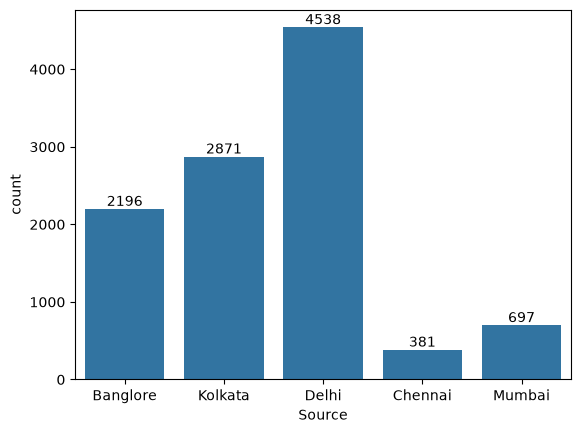

In [129]:
ax  = sns.countplot(x=df['Source'])
ax.bar_label(ax.containers[0])
plt.show()
